# Rock Property Analysis — CHANNELASSO_AV (6-class scheme)

Derive `DEFAULT_ROCK_PROPERTIES` in `diffsim/data/seismic.py` from the revised well logs in `revised_wells/`.

## Facies scheme (CHANNELASSO_AV)
| Code | Name | Lithology |
|------|------|-----------|
| 0 | Overbank | Shale |
| 1 | Channel | Sand |
| 2 | Levee | Silt |
| 3 | Cravasse | Sand |
| 4 | Coal | Coal |
| 5 | Others | Shale |

## Workflow
1. Load all `_chan_litho.las` files (discrete facies log) — these define facies intervals by depth.
2. Load matching `_vp_rhob.las` files (continuous RHOB + DTCO logs).
3. For each depth sample in `vp_rhob`, propagate the facies code from the discrete log.
4. Convert DT (µs/ft) → Vp (m/s): `Vp = 304800 / DT`.
5. Crossplot and histogram per facies; compute mean and std.
6. Update `DEFAULT_ROCK_PROPERTIES` in `seismic.py`.

In [1]:
import warnings
from pathlib import Path

import lasio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

WELLS_DIR = Path('../revised_wells')
NULL_VAL = -999.25

FACIES_NAMES = {
    0: 'Overbank',
    1: 'Channel',
    2: 'Levee',
    3: 'Cravasse',
    4: 'Coal',
    5: 'Others',
}
FACIES_COLORS = {
    0: '#8B6914',  # brown (shale)
    1: '#FFD700',  # gold (channel sand)
    2: '#90EE90',  # light green (levee silt)
    3: '#FFA500',  # orange (crevasse sand)
    4: '#2F2F2F',  # dark (coal)
    5: '#BC8F8F',  # rosy brown (others)
}

## 1. Load and merge all wells

In [2]:
def propagate_discrete_facies(chan_df, target_depths):
    """Propagate discrete facies from interval tops to continuous depth grid.
    
    Each row in chan_df defines the facies from that depth to the next row's depth.
    """
    depths = chan_df.index.values
    facies_vals = chan_df['CHANNELASSO_AV'].values
    
    result = np.full(len(target_depths), np.nan)
    for i, td in enumerate(target_depths):
        # Find the last interval top <= target depth
        idx = np.searchsorted(depths, td, side='right') - 1
        if idx >= 0:
            result[i] = facies_vals[idx]
    return result


def find_col(columns, *base_names):
    """Return first column whose base name (before ':') matches any of base_names."""
    for c in columns:
        if c.split(':')[0] in base_names:
            return c
    return None


all_records = []

vp_rhob_files = sorted(WELLS_DIR.glob('*_vp_rhob.las'))
print(f'Found {len(vp_rhob_files)} vp_rhob wells')

for vr_path in vp_rhob_files:
    well_name = vr_path.name.replace('_vp_rhob.las', '')
    chan_path = WELLS_DIR / f'{well_name}_chan_litho.las'
    
    if not chan_path.exists():
        print(f'  [skip] no chan_litho for {well_name}')
        continue
    
    try:
        vr_las = lasio.read(str(vr_path))
        ch_las = lasio.read(str(chan_path))
    except Exception as e:
        print(f'  [error] {well_name}: {e}')
        continue
    
    vr_df = vr_las.df()
    ch_df = ch_las.df()
    
    rhob_col = find_col(vr_df.columns, 'RHOB')
    dt_col   = find_col(vr_df.columns, 'DTCO', 'DT')
    if rhob_col is None or dt_col is None:
        print(f'  [skip] missing RHOB or DT/DTCO in {well_name} (cols: {vr_df.columns.tolist()})')
        continue
    
    vr_df = vr_df[[rhob_col, dt_col]].rename(columns={rhob_col: 'RHOB', dt_col: 'DTCO'})
    
    # Replace null values
    vr_df.replace(NULL_VAL, np.nan, inplace=True)
    vr_df = vr_df.dropna(subset=['RHOB', 'DTCO'])
    vr_df = vr_df[(vr_df['DTCO'] > 0) & (vr_df['RHOB'] > 0)]
    
    # Convert DT (µs/ft) → Vp (m/s)
    vr_df['VP'] = 304800.0 / vr_df['DTCO']
    
    # Propagate facies
    vr_df['FACIES'] = propagate_discrete_facies(ch_df, vr_df.index.values)
    vr_df = vr_df.dropna(subset=['FACIES'])
    vr_df['FACIES'] = vr_df['FACIES'].astype(int)
    vr_df['WELL'] = well_name
    
    all_records.append(vr_df)
    print(f'  {well_name}: {len(vr_df)} samples')

df = pd.concat(all_records, ignore_index=False)
print(f'\nTotal samples: {len(df)}')
print(df['FACIES'].value_counts().sort_index())


Found 21 vp_rhob wells
  ARTHIT-14-20: 13313 samples
  ARTHIT-14-21_ST: 10799 samples
  ARTHIT-14-24: 7590 samples
  ARTHIT-15-1X: 12942 samples
  ARTHIT-15-2X: 18262 samples
  ARTHIT-15-31: 11967 samples
  ARTHIT-16-10: 10170 samples
  ARTHIT-16-11: 9688 samples
  ARTHIT-16-8: 11732 samples
  BK-DEL-18C: 17619 samples
  BK-DEL-1: 2826 samples
  BK-DEL-22: 13692 samples
  BK-DEL-36: 16364 samples
  BK-DEL-37: 13556 samples
  BK-DEL-40: 12920 samples
  PIKUL-2X: 6346 samples
  TNY-1X: 15421 samples
  TNY-5: 7365 samples
  TONCHAN-2X: 13351 samples
  TONRANG-2X: 11474 samples
  TONSAK-7: 17428 samples

Total samples: 254825
FACIES
0    171399
1     49870
2     13505
3       913
4      7322
5     11816
Name: count, dtype: int64


## 2. Crossplot RHOB vs VP per facies

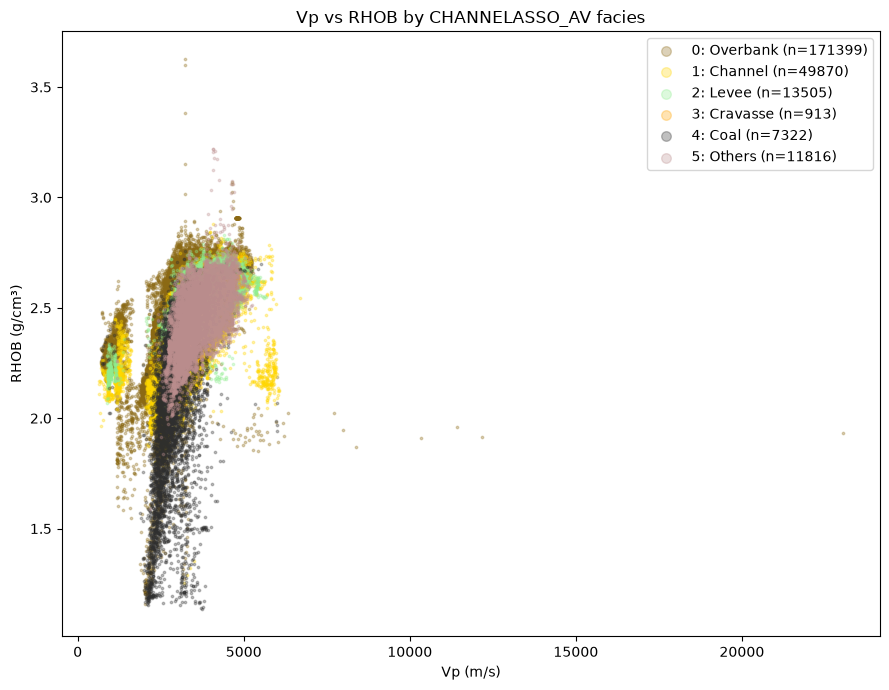

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))

for code, name in FACIES_NAMES.items():
    sub = df[df['FACIES'] == code]
    if len(sub) == 0:
        continue
    ax.scatter(sub['VP'], sub['RHOB'], s=3, alpha=0.3,
               color=FACIES_COLORS[code], label=f'{code}: {name} (n={len(sub)})')

ax.set_xlabel('Vp (m/s)')
ax.set_ylabel('RHOB (g/cm³)')
ax.set_title('Vp vs RHOB by CHANNELASSO_AV facies')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 3. Histograms per facies (RHOB and VP)

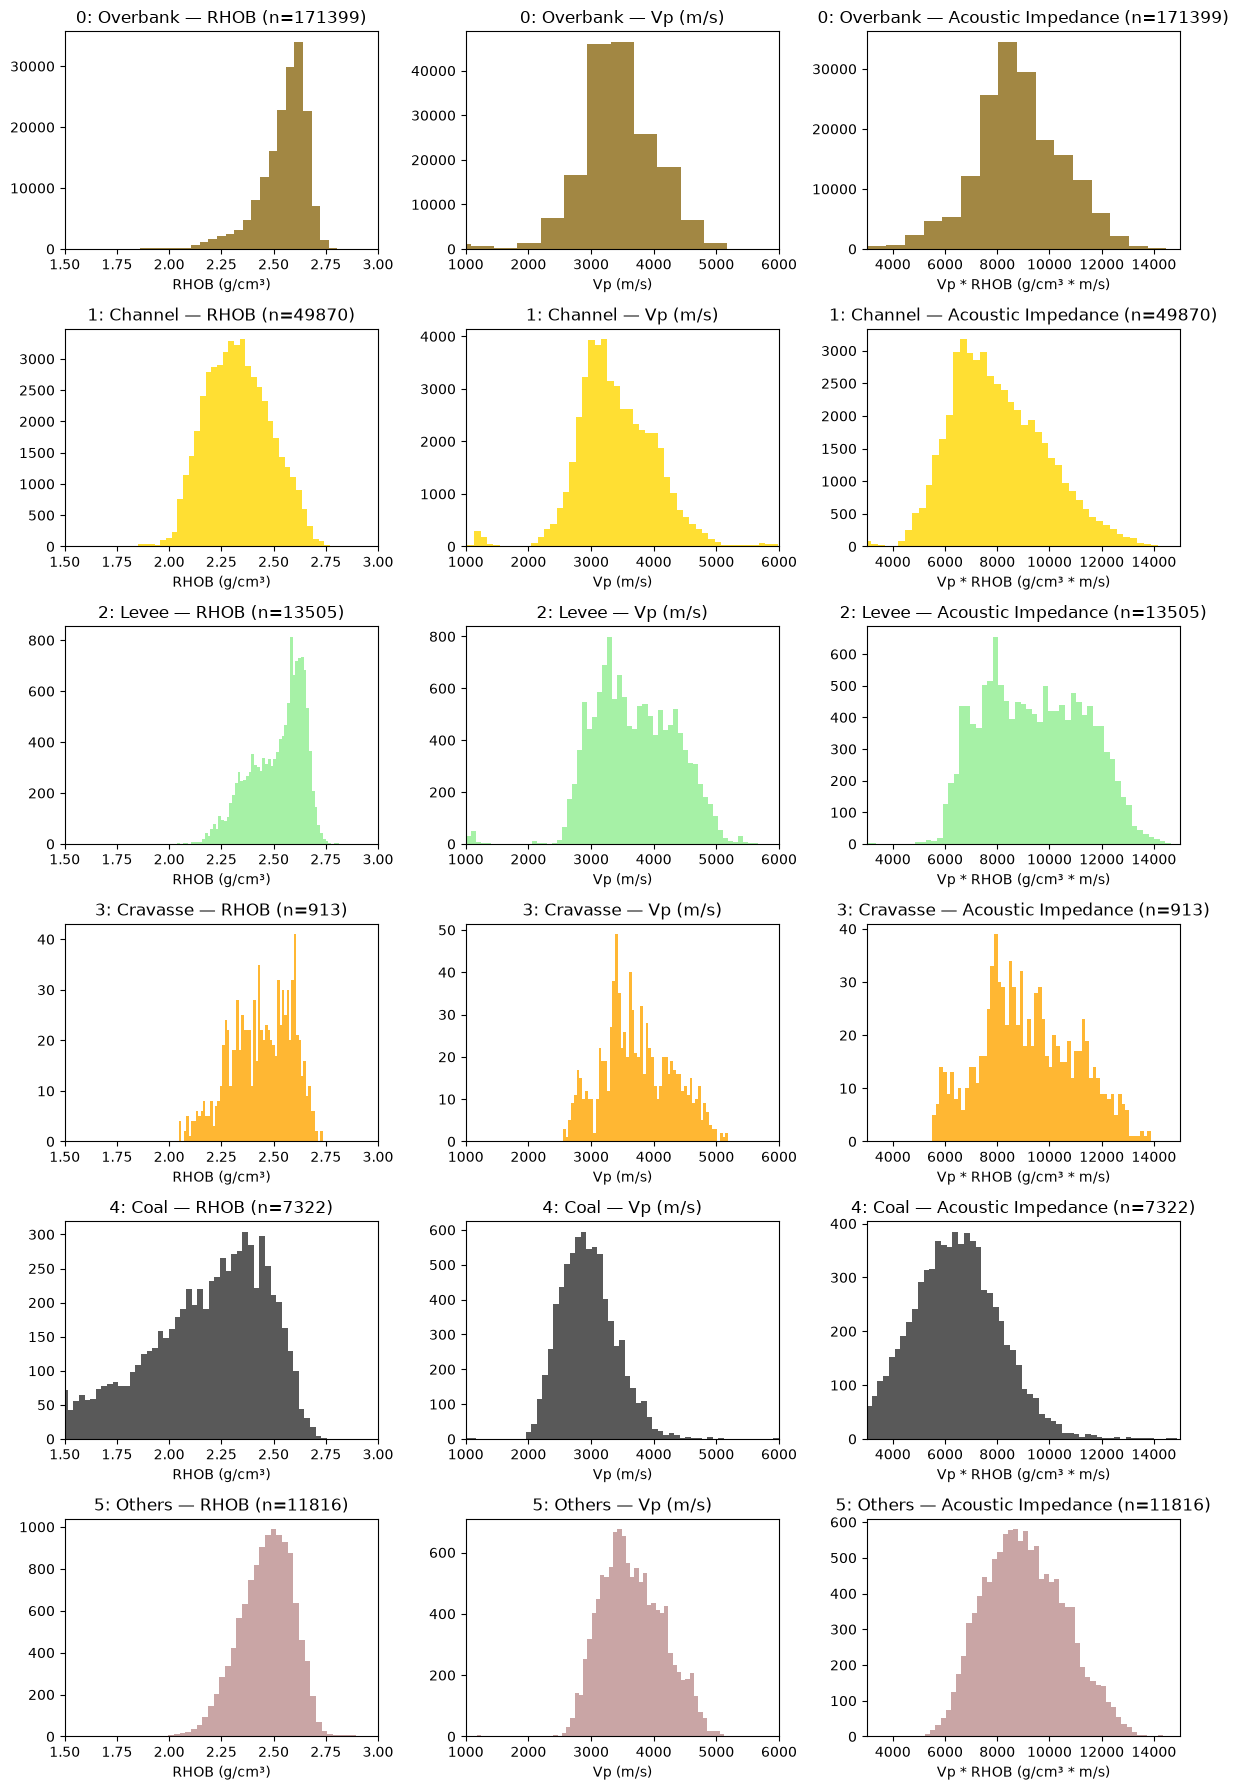

In [5]:
present_codes = sorted(df['FACIES'].unique())
n = len(present_codes)

fig, axes = plt.subplots(n, 3, figsize=(12, 3 * n))
if n == 1:
    axes = axes[np.newaxis, :]

for row, code in enumerate(present_codes):
    sub = df[df['FACIES'] == code]
    name = FACIES_NAMES.get(code, str(code))
    color = FACIES_COLORS.get(code, 'steelblue')
    
    axes[row, 0].hist(sub['RHOB'], bins=60, color=color, alpha=0.8, edgecolor='none')
    axes[row, 0].set_title(f'{code}: {name} — RHOB (n={len(sub)})')
    axes[row, 0].set_xlabel('RHOB (g/cm³)')
    axes[row, 0].set_xlim(1.5, 3.0)
    
    axes[row, 1].hist(sub['VP'], bins=60, color=color, alpha=0.8, edgecolor='none')
    axes[row, 1].set_title(f'{code}: {name} — Vp (m/s)')
    axes[row, 1].set_xlabel('Vp (m/s)')
    axes[row, 1].set_xlim(1000, 6000)



    axes[row, 2].hist(sub['VP'] * sub['RHOB'], bins=60, color=color, alpha=0.8, edgecolor='none')
    axes[row, 2].set_title(f'{code}: {name} — Acoustic Impedance (n={len(sub)})')
    axes[row, 2].set_xlabel('Vp * RHOB (g/cm³ * m/s)')
    axes[row, 2].set_xlim(3000, 15000)

plt.tight_layout()
plt.show()

## 4. Statistics per facies (mean-of-per-well-means)

In [11]:
per_well = df.groupby(['WELL', 'FACIES'])[['RHOB', 'VP']].agg(['mean', 'std'])
per_well.columns = ['RHOB_mean', 'RHOB_std', 'VP_mean', 'VP_std']
per_well = per_well.reset_index()

summary = per_well.groupby('FACIES')[['RHOB_mean', 'RHOB_std', 'VP_mean', 'VP_std']].mean()
summary.index = summary.index.astype(int)

print('Summary (mean-of-per-well-means):')
print(summary.round(2))

# Also compute global statistics for comparison
global_stats = df.groupby('FACIES')[['RHOB', 'VP']].agg(['mean', 'std'])
global_stats.columns = ['RHOB_mean', 'RHOB_std', 'VP_mean', 'VP_std']
print('\nGlobal statistics (all samples):')
print(global_stats.round(2))

Summary (mean-of-per-well-means):
        RHOB_mean  RHOB_std  VP_mean  VP_std
FACIES                                      
0            2.54      0.10  3326.86  457.54
1            2.33      0.13  3357.64  455.33
2            2.52      0.09  3601.88  423.81
3            2.44      0.09  3745.72  356.64
4            2.15      0.29  2836.65  376.72
5            2.43      0.11  3446.27  335.76

Global statistics (all samples):
        RHOB_mean  RHOB_std  VP_mean  VP_std
FACIES                                      
0            2.54      0.13  3427.62  601.07
1            2.33      0.15  3400.18  628.37
2            2.52      0.13  3663.01  714.86
3            2.44      0.15  3735.65  561.38
4            2.13      0.34  2954.37  460.44
5            2.47      0.13  3664.18  495.02


## 5. Acoustic Impedance distribution

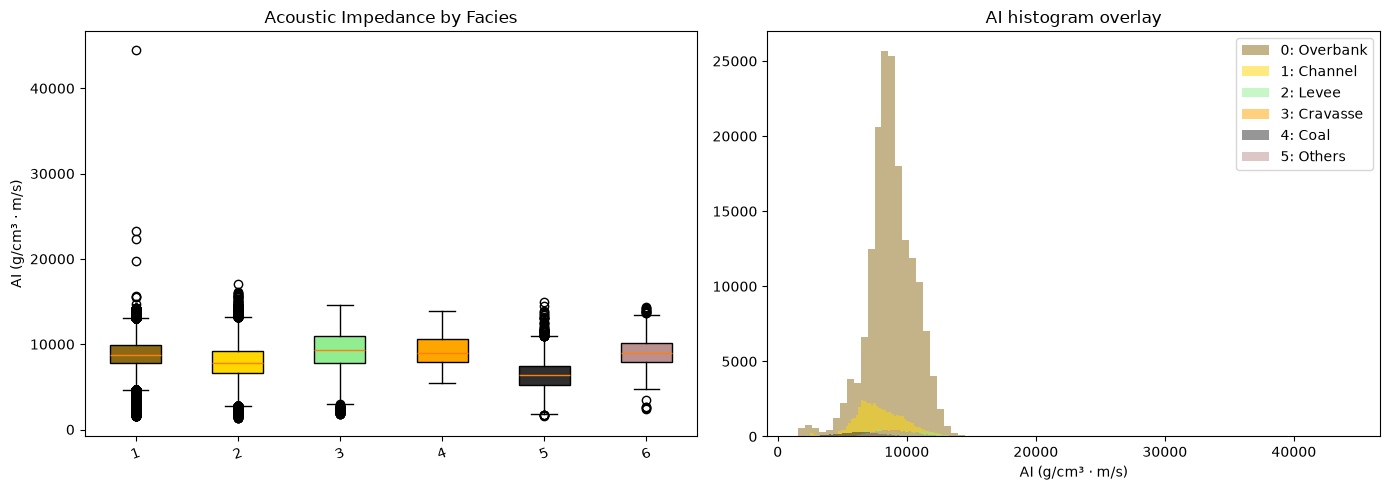

In [13]:
df['AI'] = df['RHOB'] * df['VP']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
ai_by_facies = [df[df['FACIES'] == c]['AI'].values for c in present_codes]
labels = [f"{c}: {FACIES_NAMES.get(c, str(c))}" for c in present_codes]
bp = axes[0].boxplot(ai_by_facies, patch_artist=True)
for patch, code in zip(bp['boxes'], present_codes):
    patch.set_facecolor(FACIES_COLORS.get(code, 'steelblue'))
axes[0].set_title('Acoustic Impedance by Facies')
axes[0].set_ylabel('AI (g/cm³ · m/s)')
axes[0].tick_params(axis='x', rotation=20)

# Histogram overlay
for code in present_codes:
    sub = df[df['FACIES'] == code]['AI']
    axes[1].hist(sub, bins=80, alpha=0.5, color=FACIES_COLORS.get(code, 'steelblue'),
                 label=f"{code}: {FACIES_NAMES.get(code, str(code))}")
axes[1].set_xlabel('AI (g/cm³ · m/s)')
axes[1].set_title('AI histogram overlay')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Generate DEFAULT_ROCK_PROPERTIES for seismic.py

In [14]:
# Use mean-of-per-well stats for represented facies; keep placeholders for Coal/Others
FACIES_PLACEHOLDER = {
    4: {'rhob': (1.50, 0.15), 'vp': (2500.0, 300.0)},  # Coal — not in wells
    5: {'rhob': (2.50, 0.13), 'vp': (3460.0, 420.0)},  # Others — same as overbank
}

print('DEFAULT_ROCK_PROPERTIES = {')
for code in range(6):
    name = FACIES_NAMES[code]
    if code in summary.index:
        row = summary.loc[code]
        rhob_mean = round(row['RHOB_mean'], 3)
        rhob_std  = round(row['RHOB_std'], 3)
        vp_mean   = round(row['VP_mean'], 1)
        vp_std    = round(row['VP_std'], 1)
        note = 'from well data'
    else:
        p = FACIES_PLACEHOLDER[code]
        rhob_mean, rhob_std = p['rhob']
        vp_mean, vp_std = p['vp']
        note = 'placeholder'
    print(f'    {code}: {{"rhob": ({rhob_mean}, {rhob_std}), "vp": ({vp_mean}, {vp_std})}},  # {name} — {note}')
print('}')

DEFAULT_ROCK_PROPERTIES = {
    0: {"rhob": (2.535, 0.101), "vp": (3326.9, 457.5)},  # Overbank — from well data
    1: {"rhob": (2.334, 0.134), "vp": (3357.6, 455.3)},  # Channel — from well data
    2: {"rhob": (2.516, 0.086), "vp": (3601.9, 423.8)},  # Levee — from well data
    3: {"rhob": (2.438, 0.089), "vp": (3745.7, 356.6)},  # Cravasse — from well data
    4: {"rhob": (2.152, 0.293), "vp": (2836.7, 376.7)},  # Coal — from well data
    5: {"rhob": (2.435, 0.107), "vp": (3446.3, 335.8)},  # Others — from well data
}
